# Complexite et scalabilite du raisonneur RCC8

Ce notebook evalue experimentalement la scalabilite du solveur RCC8.

On mesure:

- le nombre de regions `n`;
- le nombre de contraintes binaires stockees;
- la densite des contraintes explicites;
- une estimation de la memoire occupee par le reseau;
- le nombre theorique de triplets par passe;
- le nombre reel de passes, d'appels a `revise()` et de revisions utiles;
- le temps d'execution;
- l'effet de differents types de reseaux.

Le benchmark standard reste rapide. Un benchmark etendu permet d'aller jusqu'a 200 regions.

In [1]:
import sys
from time import perf_counter

from matplotlib import pyplot as plt

from rcc8.rcc8solver import RCC8Solver
from rcc8.relations import ALL_RELATIONS


class InstrumentedRCC8Solver(RCC8Solver):
    """Solveur identique au solveur RCC8, avec compteurs de benchmark."""

    def reset_metrics(self):
        self.pc2_passes = 0
        self.revise_calls = 0
        self.changed_revisions = 0

    def revise(self, i, j, k):
        self.revise_calls += 1
        changed = super().revise(i, j, k)
        if changed:
            self.changed_revisions += 1
        return changed

    def pc2(self):
        self.reset_metrics()
        self._normalize_network()
        self._enforce_all_converses()
        changed = True

        while changed:
            self.pc2_passes += 1
            changed = False

            for i in self.vars:
                for j in self.vars:
                    if i == j:
                        continue

                    for k in self.vars:
                        if k in (i, j):
                            continue

                        if self.revise(i, j, k):
                            changed = True

        return self.R


def build_solver(regions):
    constraints = {}
    for i in regions:
        for j in regions:
            if i != j:
                constraints[(i, j)] = set(ALL_RELATIONS)
    return InstrumentedRCC8Solver(list(regions), constraints)


def count_binary_constraints(n):
    return n * (n - 1)


def count_undirected_pairs(n):
    return n * (n - 1) // 2


def count_ordered_triplets(n):
    return n * (n - 1) * (n - 2)


def deep_getsizeof(obj, seen=None):
    """Estimation recursive de la taille memoire d'un objet Python."""
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)

    size = sys.getsizeof(obj)
    if isinstance(obj, dict):
        size += sum(deep_getsizeof(k, seen) + deep_getsizeof(v, seen) for k, v in obj.items())
    elif isinstance(obj, (list, tuple, set, frozenset)):
        size += sum(deep_getsizeof(item, seen) for item in obj)

    return size


def estimate_solver_memory(solver):
    """Estime la memoire du reseau: variables + matrice de contraintes."""
    return deep_getsizeof(solver.vars) + deep_getsizeof(solver.R)


def add_scenario_constraints(solver, scenario):
    regions = solver.vars

    if scenario == "empty":
        return 0

    if scenario == "sparse_dc":
        added = 0
        for index in range(0, len(regions) - 1, 4):
            solver.add_constraint(regions[index], regions[index + 1], {"DC"})
            added += 1
        return added

    if scenario == "chain_tpp":
        for index in range(len(regions) - 1):
            solver.add_constraint(regions[index], regions[index + 1], {"TPP"})
        return len(regions) - 1

    raise ValueError(f"Unknown scenario: {scenario}")


def benchmark_solver(n, scenario):
    regions = tuple(f"R{i}" for i in range(n))
    solver = build_solver(regions)
    explicit_constraints = add_scenario_constraints(solver, scenario)
    memory_before = estimate_solver_memory(solver)

    start = perf_counter()
    solver.pc2()
    elapsed = perf_counter() - start
    memory_after = estimate_solver_memory(solver)

    possible_explicit = max(count_undirected_pairs(n), 1)
    explicit_density = explicit_constraints / possible_explicit

    return {
        "n": n,
        "scenario": scenario,
        "explicit_constraints": explicit_constraints,
        "explicit_density": explicit_density,
        "stored_constraints": count_binary_constraints(n),
        "stored_density": 1.0,
        "triplets_per_pass": count_ordered_triplets(n),
        "pc2_passes": solver.pc2_passes,
        "revise_calls": solver.revise_calls,
        "changed_revisions": solver.changed_revisions,
        "memory_before_mb": memory_before / (1024 * 1024),
        "memory_after_mb": memory_after / (1024 * 1024),
        "time": elapsed,
    }


def print_results(results):
    print(
        f"{'scenario':>12} | {'n':>5} | {'exp':>5} | {'densite':>8} | "
        f"{'stockees':>9} | {'tri/passe':>10} | {'passes':>6} | {'revise':>10} | "
        f"{'utiles':>7} | {'mem av.':>8} | {'mem ap.':>8} | {'temps':>10}"
    )
    print("-" * 136)
    for result in results:
        print(
            f"{result['scenario']:>12} | {result['n']:5d} | "
            f"{result['explicit_constraints']:5d} | {result['explicit_density']:8.3f} | "
            f"{result['stored_constraints']:9d} | {result['triplets_per_pass']:10d} | "
            f"{result['pc2_passes']:6d} | {result['revise_calls']:10d} | "
            f"{result['changed_revisions']:7d} | "
            f"{result['memory_before_mb']:7.2f}M | {result['memory_after_mb']:7.2f}M | "
            f"{result['time']:9.4f}s"
        )

## 1. Croissance theorique

Le reseau stocke une contrainte pour chaque paire ordonnee `(i, j)`, donc `n(n-1)` contraintes. Une passe complete de PC-2 parcourt des triplets ordonnes, donc `n(n-1)(n-2)` triplets. Le benchmark instrumente aussi le nombre reel de passes et d'appels a `revise()` jusqu'au point fixe.

La densite explicite correspond ici au rapport entre contraintes donnees par l'utilisateur et paires non orientees possibles.

In [2]:
theoretical_sizes = [10, 20, 50, 100, 150, 200]

print(f"{'n':>5} | {'paires':>10} | {'contraintes':>12} | {'triplets':>12}")
print("-" * 50)
for n in theoretical_sizes:
    print(
        f"{n:5d} | {count_undirected_pairs(n):10d} | "
        f"{count_binary_constraints(n):12d} | {count_ordered_triplets(n):12d}"
    )

assert count_undirected_pairs(200) == 19900
assert count_binary_constraints(200) == 39800
assert count_ordered_triplets(200) == 7880400

    n |     paires |  contraintes |     triplets
--------------------------------------------------
   10 |         45 |           90 |          720
   20 |        190 |          380 |         6840
   50 |       1225 |         2450 |       117600
  100 |       4950 |         9900 |       970200
  150 |      11175 |        22350 |      3307800
  200 |      19900 |        39800 |      7880400


## 2. Scenarios de benchmark

On compare trois scenarios:

- `empty`: aucune contrainte explicite, tous les domaines restent larges;
- `sparse_dc`: quelques contraintes `DC` independantes;
- `chain_tpp`: chaine d'inclusions `R0 TPP R1`, `R1 TPP R2`, etc.

La colonne `densite` mesure la densite des contraintes explicites, pas la densite de stockage interne. Le stockage interne est dense par construction, car la matrice contient toutes les paires.

In [3]:
standard_sizes = [10, 20, 50, 100]
scenarios = ["empty", "sparse_dc", "chain_tpp"]
standard_results = []

for scenario in scenarios:
    for n in standard_sizes:
        standard_results.append(benchmark_solver(n, scenario))

print_results(standard_results)
assert len(standard_results) == len(scenarios) * len(standard_sizes)

    scenario |     n |   exp |  densite |  stockees |  tri/passe | passes |     revise |  utiles |  mem av. |  mem ap. |      temps
----------------------------------------------------------------------------------------------------------------------------------------
       empty |    10 |     0 |    0.000 |        90 |        720 |      1 |        720 |       0 |    0.07M |    0.07M |    0.0116s
       empty |    20 |     0 |    0.000 |       380 |       6840 |      1 |       6840 |       0 |    0.30M |    0.30M |    0.0977s
       empty |    50 |     0 |    0.000 |      2450 |     117600 |      1 |     117600 |       0 |    1.91M |    1.91M |    1.1799s
       empty |   100 |     0 |    0.000 |      9900 |     970200 |      1 |     970200 |       0 |    7.69M |    7.69M |    7.6579s
   sparse_dc |    10 |     3 |    0.067 |        90 |        720 |      1 |        720 |       0 |    0.07M |    0.07M |    0.0058s
   sparse_dc |    20 |     5 |    0.026 |       380 |       6840 |     

## 3. Visualisation comparative

Cette courbe compare les scenarios sur les tailles standards.

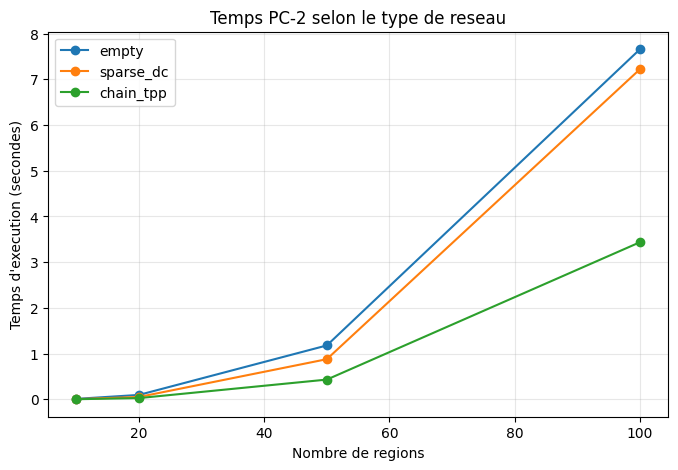

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

for scenario in scenarios:
    scenario_results = [r for r in standard_results if r["scenario"] == scenario]
    ax.plot(
        [r["n"] for r in scenario_results],
        [r["time"] for r in scenario_results],
        marker="o",
        label=scenario,
    )

ax.set_title("Temps PC-2 selon le type de reseau")
ax.set_xlabel("Nombre de regions")
ax.set_ylabel("Temps d'execution (secondes)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 4. Benchmark etendu jusqu'a 200 regions

Le bloc suivant va jusqu'a 200 regions pour le scenario `empty`. C'est volontairement limite a un seul scenario, car 200 regions representent deja presque 8 millions de triplets par passe.

Par defaut, il est desactive pour garder le notebook rapide a rejouer. Mettre `RUN_EXTENDED_TO_200 = True` pour lancer ce benchmark long.

In [5]:
RUN_EXTENDED_TO_200 = False

extended_results = []
if RUN_EXTENDED_TO_200:
    for n in [10, 20, 50, 100, 150, 200]:
        extended_results.append(benchmark_solver(n, "empty"))
    print_results(extended_results)
else:
    print("Benchmark etendu desactive.")

assert RUN_EXTENDED_TO_200 is False or extended_results[-1]["n"] == 200

Benchmark etendu desactive.


## 5. Courbes du benchmark etendu

Ces courbes permettent de voir le saut de cout entre 100, 150 et 200 regions, en temps et en memoire estimee.

In [6]:
if extended_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot([r["n"] for r in extended_results], [r["time"] for r in extended_results], marker="o", color="#C0392B")
    axes[0].set_title("Temps jusqu'a 200 regions")
    axes[0].set_xlabel("Nombre de regions")
    axes[0].set_ylabel("Temps d'execution (secondes)")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot([r["n"] for r in extended_results], [r["memory_after_mb"] for r in extended_results], marker="s", color="#1F618D")
    axes[1].set_title("Memoire estimee du reseau")
    axes[1].set_xlabel("Nombre de regions")
    axes[1].set_ylabel("Memoire estimee (MB)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Pas de donnees etendues a afficher.")

Pas de donnees etendues a afficher.


## 6. Temps par triplet et memoire par contrainte

Ces ratios donnent une intuition du cout unitaire. Le temps est rapporte aux appels reels a `revise()`, qui integrent automatiquement le nombre de passes jusqu'au point fixe.

In [7]:
reference_results = extended_results if extended_results else [r for r in standard_results if r["scenario"] == "empty"]

for result in reference_results:
    per_revise = result["time"] / max(result["revise_calls"], 1)
    memory_per_constraint = result["memory_after_mb"] / max(result["stored_constraints"], 1)
    print(
        f"n={result['n']:>3} | temps/revise={per_revise:.10f}s | "
        f"passes={result['pc2_passes']:>2} | revise={result['revise_calls']:>8} | "
        f"memoire/contrainte={memory_per_constraint:.8f} MB"
    )

n= 10 | temps/revise=0.0000161391s | passes= 1 | revise=     720 | memoire/contrainte=0.00081164 MB
n= 20 | temps/revise=0.0000142909s | passes= 1 | revise=    6840 | memoire/contrainte=0.00079993 MB
n= 50 | temps/revise=0.0000100331s | passes= 1 | revise=  117600 | memoire/contrainte=0.00077843 MB
n=100 | temps/revise=0.0000078931s | passes= 1 | revise=  970200 | memoire/contrainte=0.00077706 MB


## 7. Interpretation

Observations importantes:

- Le nombre de contraintes stockees croit en `O(n^2)`.
- Le nombre de triplets parcourus par passe croit en `O(n^3)`.
- Le nombre reel d'appels a `revise()` vaut `passes * n(n-1)(n-2)` dans cette implementation.
- Le stockage interne est dense: meme avec peu de contraintes explicites, toutes les paires de regions existent dans la matrice.
- La densite explicite varie selon le scenario, mais la densite de stockage reste a 1.
- La memoire estimee augmente principalement avec le nombre de paires stockees.
- Aller a 200 regions est possible pour un benchmark, mais deja couteux.
- Aller a 1000 regions n'est pas realiste avec cette implementation pedagogique.

Ameliorations possibles:

- utiliser une file de propagation au lieu de reparcourir tous les triplets;
- eviter les revisions inutiles;
- distinguer contraintes explicites et contraintes deduites;
- stocker les relations sous forme de bitsets pour accelerer les intersections et reduire la memoire.